# Clustering Jerarquico

In [4]:
import numpy as np # Para realizar cálculos avanzados
import pandas as pd #Contiene funciones que nos ayudan en el análisis de datos
import matplotlib.pyplot as plt #Para crear gráficos de muy buena calidad

import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

%matplotlib inline

Importando los datos

In [6]:
Estudiantes = pd.read_csv('C:/Users/Usuario/Desktop/DiploDataScience/Modulo3/Cluster Jerarquico/datos/estudiantes.csv', engine='python', index_col=0)

Vemos el tipo de variables que contiene el objeto Estudiantes

In [7]:
Estudiantes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, Lucia to Maria
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Matematicas  10 non-null     float64
 1   Ciencias     10 non-null     float64
 2   Espanol      10 non-null     float64
 3   Historia     10 non-null     float64
 4   Deportes     10 non-null     float64
dtypes: float64(5)
memory usage: 480.0+ bytes


Desplegamos las primeras filas

In [8]:
Estudiantes.head()

,Matematicas,Ciencias,Espanol,Historia,Deportes
Estudiante,,,,,
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3


Obtenemos los valores de las calificaciones para llevar a cabo el análisis de datos.

In [10]:
calificaciones = Estudiantes.iloc[:, [0,1,2,3,4]].values
calificaciones

array([[7. , 6.5, 9.2, 8.6, 8. ],
       [7.5, 9.4, 7.3, 7. , 7. ],
       [7.6, 9.2, 8. , 8. , 7.5],
       [5. , 6.5, 6.5, 7. , 9. ],
       [6. , 6. , 7.8, 8.9, 7.3],
       [7.8, 9.6, 7.7, 8. , 6.5],
       [6.3, 6.4, 8.2, 9. , 7.2],
       [7.9, 9.7, 7.5, 8. , 6. ],
       [6. , 6. , 6.5, 5.5, 8.7],
       [6.8, 7.2, 8.7, 9. , 7. ]])

**Creando el Dendrograma del Clustering Jerárquico**

In [12]:
Clustering_Jerarquico = linkage(calificaciones, 'ward') #Utilizamos el método Ward para agrupar los clusters

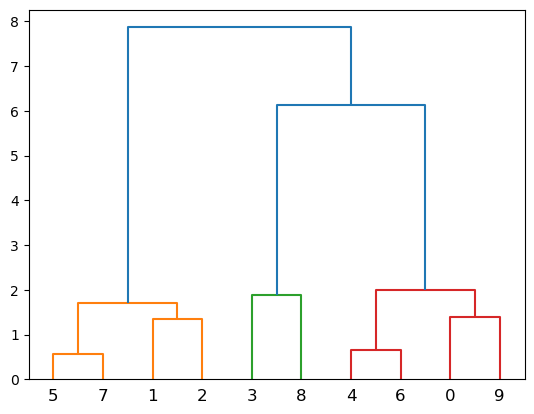

In [13]:
dendrogram = sch.dendrogram(Clustering_Jerarquico)

In [14]:
clusters = fcluster(Clustering_Jerarquico, t=2, criterion = 'distance') #t es la altura a la que haremos el corte del dendrograma

In [15]:
clusters

array([3, 1, 1, 2, 3, 1, 3, 1, 2, 3], dtype=int32)

Agregando la clasificación al archivo original

In [17]:
Estudiantes['Clustering Jerarquico'] = clusters
Estudiantes

,Matematicas,Ciencias,Espanol,Historia,Deportes,Clustering Jerarquico
Estudiante,,,,,,
Lucia,7.0,6.5,9.2,8.6,8.0,3
Pedro,7.5,9.4,7.3,7.0,7.0,1
Ines,7.6,9.2,8.0,8.0,7.5,1
Luis,5.0,6.5,6.5,7.0,9.0,2
Andres,6.0,6.0,7.8,8.9,7.3,3
Ana,7.8,9.6,7.7,8.0,6.5,1
Carlos,6.3,6.4,8.2,9.0,7.2,3
Jose,7.9,9.7,7.5,8.0,6.0,1
Sonia,6.0,6.0,6.5,5.5,8.7,2


Lo grabamos en el disco duro ya con los clusters asignados

In [19]:
Estudiantes.to_csv('C:/Users/Usuario/Desktop/DiploDataScience/Modulo3/Cluster Jerarquico/Estudiantes Cluster Jerarquico.csv')